In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import confusion_matrix

def print_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)    # 맞힌 개수 / 전체 개수
    print(f"1. Accuracy: {acc:.4f}")

    re = recall_score(y_true, y_pred, average='macro')     # TP / (TP + FN)
    print(f"2. Recall: {re:.4f}")

    pr = precision_score(y_true, y_pred, average='macro')    # TP / (TP + FP)
    print(f"3. Precision: {pr:.4f}")

    f1 = f1_score(y_true, y_pred, average='macro')       # (2 * Precision * Recall) / (Precision + Recall)
    print(f"4. F1 Score: {f1:.4f}")

    # (정답, 예측값) 순서대로 지정한다!!!
    cfm = confusion_matrix(y_true, y_pred)
    s = sns.heatmap(cfm, annot=True, cmap='Blues', fmt='d', cbar=False)
    s.set(xlabel='Prediction', ylabel='Actual')
    plt.show()

# PCA (Principal Component Analysis)

## Unsupervised Learning 중 Dimensionality Reduction의 방법 중 하나

Scaling 후 PCA 수행

### 데이터 읽어오기

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
ha_test = pd.read_csv('/content/drive/MyDrive/fly ai/dataset/HumanActivityRecognition/test.csv')
ha_train = pd.read_csv('/content/drive/MyDrive/fly ai/dataset/HumanActivityRecognition/train.csv')

In [ ]:
ha_train.shape, ha_test.shape

((7352, 563), (2947, 563))

In [ ]:
ha = pd.concat([ha_train, ha_test])

In [ ]:
ha.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


### EDA

In [ ]:
ha.describe()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject
count,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,...,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000
mean,0.274347,-0.017743,-0.108925,-0.607784,-0.510191,-0.613064,-0.633593,-0.525697,-0.614989,-0.466732,...,-0.298592,-0.617700,0.007705,0.002648,0.017683,-0.009219,-0.496522,0.063255,-0.054284,16.146422
std,0.067628,0.037128,0.053033,0.438694,0.500240,0.403657,0.413333,0.484201,0.399034,0.538707,...,0.320199,0.308796,0.336591,0.447364,0.616188,0.484770,0.511158,0.305468,0.268898,8.679067
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000
25%,0.262625,-0.024902,-0.121019,-0.992360,-0.976990,-0.979137,-0.993293,-0.977017,-0.979064,-0.935788,...,-0.536174,-0.841847,-0.124694,-0.287031,-0.493108,-0.389041,-0.817288,0.002151,-0.131880,9.000000
50%,0.277174,-0.017162,-0.108596,-0.943030,-0.835032,-0.850773,-0.948244,-0.843670,-0.845068,-0.874825,...,-0.335160,-0.703402,0.008146,0.007668,0.017192,-0.007186,-0.715631,0.182028,-0.003882,17.000000
75%,0.288354,-0.010625,-0.097589,-0.250293,-0.057336,-0.278737,-0.302033,-0.087405,-0.288149,-0.014641,...,-0.113167,-0.487981,0.149005,0.291490,0.536137,0.365996,-0.521503,0.250790,0.102970,24.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,30.000000


In [ ]:
ha['Activity'].value_counts()

,count
Activity,
LAYING,1944
STANDING,1906
SITTING,1777
WALKING,1722
WALKING_UPSTAIRS,1544
WALKING_DOWNSTAIRS,1406


#### 결측치 확인

In [ ]:
ha.isna().any().sum()

np.int64(0)

any까지 하면, 각 항목 별로 NaN 있는지 없는지 나옴.

이 값을 모든 항목에서 더한게 0이므로, 아무 항에도 결측치가 없다.

### 데이터 분리

In [ ]:
x_train = ha_train.drop(['Activity', 'subject'], axis=1)
y_train = ha_train['Activity']

### 데이터 전처리

#### Encoding

y의 Activity, subject 필요


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_e = le.fit_transform(y_train)

#### Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_s = scaler.fit_transform(x_train)

### PCA 차원축소


In [ ]:
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(x_train_s)

PCA()

In [ ]:
pca.explained_variance_ratio_

array([5.07811723e-01, 6.58068027e-02, 2.80643677e-02, 2.50395275e-02,
       1.88828501e-02, 1.72400642e-02, 1.37101147e-02, 1.19907768e-02,
       9.95859511e-03, 9.65086590e-03, 8.60051649e-03, 8.00280950e-03,
       7.63996369e-03, 6.45328924e-03, 6.32324346e-03, 5.99722090e-03,
       5.86750302e-03, 5.75407392e-03, 5.67921047e-03, 5.27295779e-03,
       5.00362925e-03, 4.88408406e-03, 4.78205784e-03, 4.68562930e-03,
       4.49289260e-03, 4.21027243e-03, 4.17978682e-03, 4.05570369e-03,
       3.88524168e-03, 3.87018044e-03, 3.65958878e-03, 3.54553381e-03,
       3.47942606e-03, 3.37187109e-03, 3.29676999e-03, 3.28215050e-03,
       3.20529478e-03, 2.95614939e-03, 2.86722415e-03, 2.85074548e-03,
       2.68766324e-03, 2.65619859e-03, 2.63405989e-03, 2.58850596e-03,
       2.49054872e-03, 2.46954034e-03, 2.40679913e-03, 2.36115075e-03,
       2.30278857e-03, 2.27567245e-03, 2.20164699e-03, 2.13466984e-03,
       2.07704456e-03, 2.02496620e-03, 1.99779441e-03, 1.97750625e-03,
      

#### *** 이 분산을 cumulative sum 해서, 80%가 될때까지 필요한 데이터 개수를 구하는 것이 목표

In [ ]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
num_var = np.argmax(cumulative_variance >= 0.80) + 1
num_var

np.int64(26)

#### PCA 적용

In [ ]:
pca = PCA(n_components=num_var, random_state=SEED)
pca.fit(x_train_s)
x_train_s_p = pca.transform(x_train_s)

columns = [f'PC_{i+1}' for i in range(num_var)]
x_train_pca = pd.DataFrame(data=x_train_s_p, columns=columns, index=x_train.index)

In [ ]:
x_train_pca

,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,...,PC_17,PC_18,PC_19,PC_20,PC_21,PC_22,PC_23,PC_24,PC_25,PC_26
0,-16.138544,2.152024,-3.144780,0.272464,-6.798938,-4.249394,2.937159,-4.905413,0.775515,3.627737,...,1.700568,-3.939219,2.127305,-0.075840,-2.831640,3.298593,0.565132,-1.654967,0.279873,-4.124464
1,-15.296194,1.387144,0.682221,-2.813677,-4.266170,-2.055663,0.011205,-1.845985,-0.492546,0.180175,...,-0.693087,-0.060562,0.991346,0.074259,-1.424176,1.579882,1.225787,0.073037,1.178698,0.703850
2,-15.137019,2.473351,1.756641,-3.717974,-4.181557,-1.357518,0.072947,-1.388188,-0.539754,0.671712,...,0.249115,0.879679,0.226115,-0.066216,-0.308190,0.525031,0.712462,-0.148489,0.364532,0.994000
3,-15.350884,3.915681,1.790322,-2.567521,-3.205840,-0.942944,0.530736,-1.832185,-1.071517,1.496989,...,-0.009838,-0.355311,-1.341817,-0.537152,0.739978,1.451162,-0.614207,-2.187956,0.429484,1.376196
4,-15.544814,4.598737,2.188582,-2.897578,-3.080150,-1.061458,-1.048591,-0.816933,-0.600063,-1.118875,...,-2.236419,1.349518,-1.863741,0.336329,0.733567,-2.141854,-0.038362,-0.847268,0.388234,0.960477
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7347,15.465060,-12.536306,-1.999177,-3.457724,1.523194,-2.699127,-3.561252,2.418693,-0.383180,-1.308722,...,0.906253,1.183145,-1.551912,-1.598945,0.594288,-0.808614,-1.584973,-2.865675,0.316024,-0.856764
7348,14.222722,-10.253501,-2.377660,-2.802667,1.325313,-4.346117,-2.193966,0.032140,0.528929,-0.702509,...,1.444969,0.427731,-0.636166,-0.759174,-0.839133,0.451364,-1.658942,-2.854394,0.008785,-0.255916
7349,14.333436,-12.260712,-4.025946,-3.849780,2.860490,-3.624049,-3.929641,-0.873163,0.746331,1.575526,...,-3.043597,-0.200254,-0.721553,-2.558095,-1.902208,0.346729,-0.004472,-3.289796,0.266732,0.402953
7350,12.876019,-14.071256,-2.916061,-5.013426,3.938225,-2.137607,-5.390400,0.321305,0.916300,1.646371,...,-4.889324,-0.904276,-1.815940,-1.689178,0.925770,-0.947808,0.361296,-1.703236,0.480305,1.029873


In [ ]:
x_train_pca = x_train_pca.to_numpy()

### 학습

#### 최종 데이터 : x_train_pca, y_train_e

#### Decision Tree

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(random_state=SEED)

param_grid = {
    'max_depth' : [3,4,5],
    'min_samples_split' : [2,5,10],
    'criterion' : ['gini', 'entropy']
        }

grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

grid_search.fit(x_train_pca, y_train_e)

best_model_decision_tree = grid_search.best_estimator_

##### Tree Plot

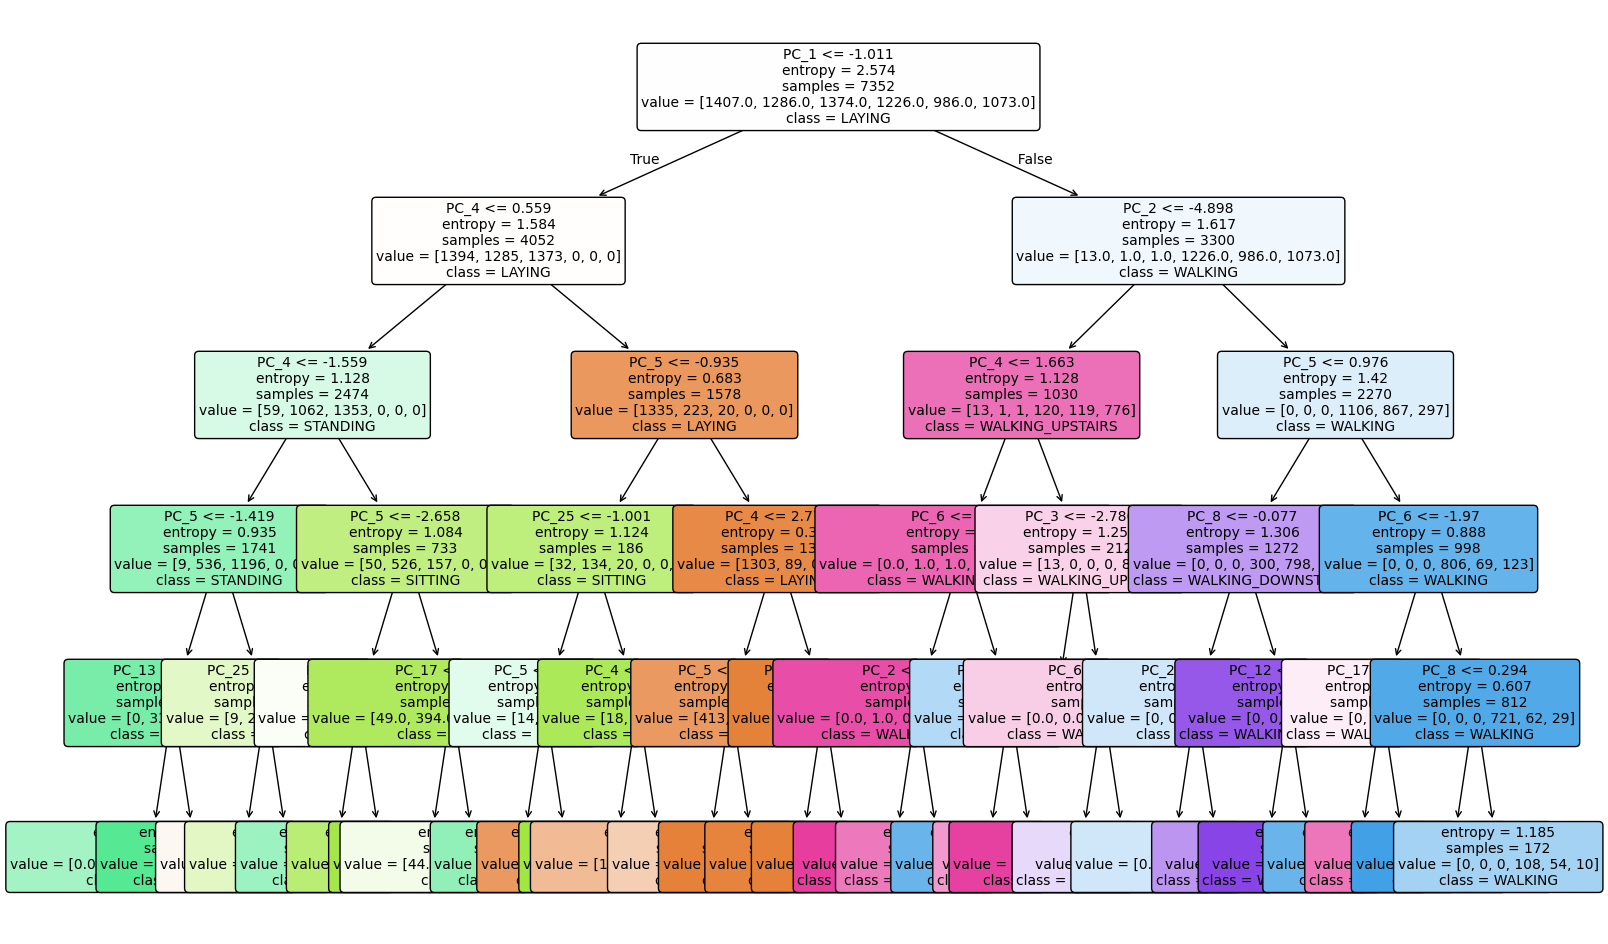

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 12))
plot_tree(
    decision_tree=grid_search.best_estimator_,
    feature_names=columns,
    class_names=le.classes_,
    filled=True,
    rounded=True,
    proportion=False,
    fontsize=10
)
plt.show()

#### SVM

In [ ]:
from sklearn.svm import SVC

clf = SVC(random_state=SEED)

param_grid = {
    'C' : [0.01, 0.1, 1.0, 10],
    'gamma' : ['scale', 'auto'],
    'kernel' : ['rbf', 'poly']
        }

grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

grid_search.fit(x_train_pca, y_train_e)

best_model_svm = grid_search.best_estimator_

#### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(random_state=SEED)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

grid_search.fit(x_train_pca, y_train_e)

best_model_rf = grid_search.best_estimator_

### 테스트 데이터셋

#### 전처리

In [ ]:
x_test = ha_test.drop(['Activity','subject'], axis=1)
y_test = ha_test['Activity']

####*** Test 데이터셋에는 fit_transform 아니고 그냥 transform

In [ ]:
y_test_e = le.transform(y_test)

In [ ]:
x_test_s = scaler.transform(x_test)

#### PCA

'fit' 은 train에서만 해야되는거 잊지 말기

In [ ]:
pca = PCA()
pca.fit(x_train_s)    # fit은 train 가지고 함

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
num_var = np.argmax(cumulative_variance >= 0.80) + 1

pca = PCA(n_components=num_var, random_state=SEED)
pca.fit(x_train_s)
x_test_s_p = pca.transform(x_test_s)

columns = [f'PC_{i+1}' for i in range(num_var)]
x_test_pca = pd.DataFrame(data=x_test_s_p, columns=columns, index=x_test.index)

x_test_pca = x_test_pca.to_numpy()

### 모델별 테스트

최종 데이터셋 : x_test_pca, y_test_e

#### Decision Tree

1. Accuracy: 0.7465
2. Recall: 0.7366
3. Precision: 0.7502
4. F1 Score: 0.7354


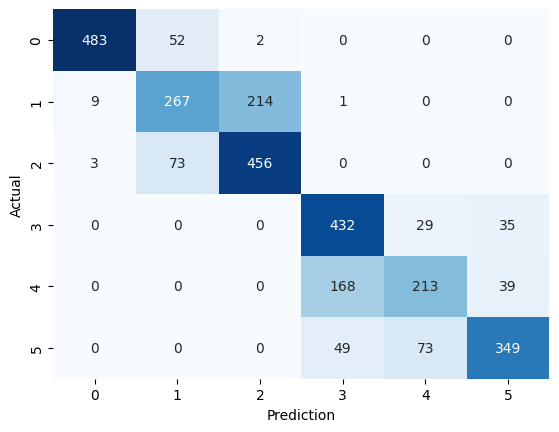

In [ ]:
y_predict_dt = best_model_decision_tree.predict(x_test_pca)

print_metrics(y_test_e, y_predict_dt)

#### SVM

1. Accuracy: 0.7465
2. Recall: 0.7366
3. Precision: 0.7502
4. F1 Score: 0.7354


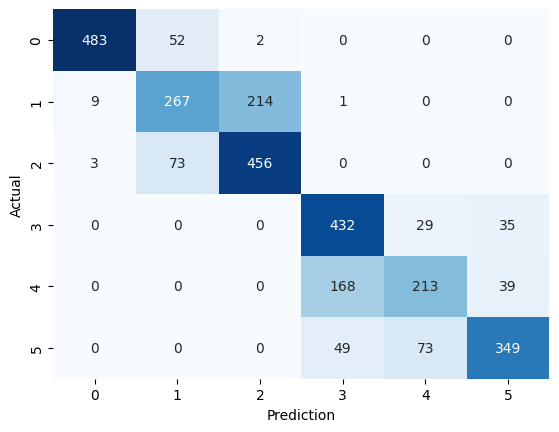

In [ ]:
y_predict_svm = best_model_svm.predict(x_test_pca)

print_metrics(y_test_e, y_predict_dt)

#### Random Forest

1. Accuracy: 0.8636
2. Recall: 0.8593
3. Precision: 0.8679
4. F1 Score: 0.8605


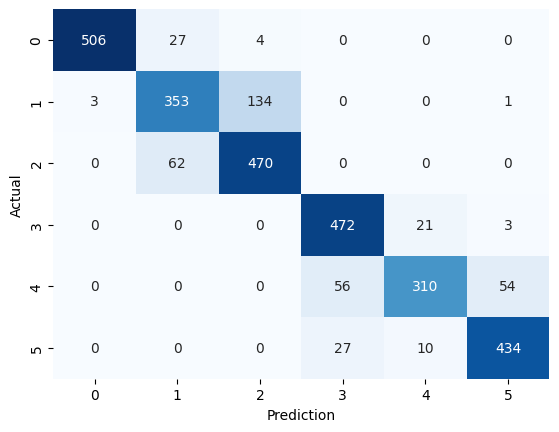

In [ ]:
y_predict_rf = best_model_rf.predict(x_test_pca)

print_metrics(y_test_e, y_predict_rf)